# Gender Participation in Sports

Total Revenue of MenAndWomen vs. SportParticipation by Gender and by Year

Total Expenditure of MenAndWomen vs. SportParticipation by Gender and by Year

https://www.kaggle.com/datasets/umerhaddii/us-collegiate-sports-dataset

STILL A WORK IN PROGRESS, BUT HERE IS SOME BASE CODE - CASS

WILL NEED TO CLEAN CODE FURTHER FOR NA ROWS ETC.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sports.csv")
#df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'sports.csv'

In [ ]:
# revenue vs. participation

In [ ]:
sports2 = df.copy()
sports2.columns = sports2.columns.str.strip().str.lower()

In [ ]:
sports2 = sports2.drop(columns=['unitid', 'institution_name', 'city_txt', 'state_cd', 'zip_text', 'classification_code', 'classification_name', 'classification_other'])
#sports2[:5]

In [ ]:
sports2 = sports2.drop(columns=['sector_cd', 'sector_name', 'sportscode'])
sports2[:10]

,year,ef_male_count,ef_female_count,ef_total_count,partic_men,partic_women,partic_coed_men,partic_coed_women,sum_partic_men,sum_partic_women,rev_men,rev_women,total_rev_menwomen,exp_men,exp_women,total_exp_menwomen,sports
0,2015,1923,2300,4223,31.0,NaN,NaN,NaN,31,0,345592.0,NaN,345592.0,397818.0,NaN,397818.0,Baseball
1,2015,1923,2300,4223,19.0,16.0,NaN,NaN,19,16,1211095.0,748833.0,1959928.0,817868.0,742460.0,1560328.0,Basketball
2,2015,1923,2300,4223,61.0,46.0,NaN,NaN,61,46,183333.0,315574.0,498907.0,246949.0,251184.0,498133.0,All Track Combined
3,2015,1923,2300,4223,99.0,NaN,NaN,NaN,99,0,2808949.0,NaN,2808949.0,3059353.0,NaN,3059353.0,Football
4,2015,1923,2300,4223,9.0,NaN,NaN,NaN,9,0,78270.0,NaN,78270.0,83913.0,NaN,83913.0,Golf
5,2015,1923,2300,4223,NaN,21.0,NaN,NaN,0,21,NaN,410717.0,410717.0,NaN,432648.0,432648.0,Soccer
6,2015,1923,2300,4223,NaN,25.0,NaN,NaN,0,25,NaN,298164.0,298164.0,NaN,340259.0,340259.0,Softball
7,2015,1923,2300,4223,7.0,10.0,NaN,NaN,7,10,78274.0,131145.0,209419.0,99612.0,113886.0,213498.0,Tennis
8,2015,1923,2300,4223,NaN,16.0,NaN,NaN,0,16,NaN,321329.0,321329.0,NaN,357485.0,357485.0,Volleyball
9,2015,1923,2300,4223,NaN,9.0,NaN,NaN,0,9,NaN,127376.0,127376.0,NaN,115216.0,115216.0,Bowling


In [ ]:
#sports2['year'].value_counts()

In [ ]:
#sports2['men_partic_exp'] = sports2['sum_partic_men'] / sports2['total_exp_menwomen'].replace(0, np.nan)
#sports2['women_partic_exp'] = sports2['sum_partic_women'] / sports2['total_exp_menwomen'].replace(0, np.nan)

In [ ]:
#sports2[:5]

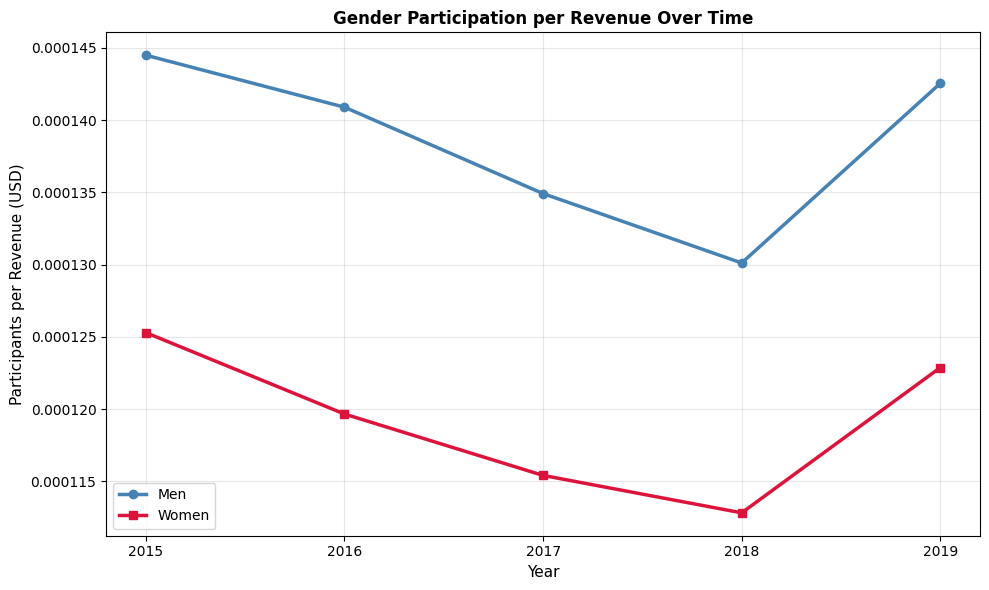

In [ ]:
# PARTICIPATION VS. REVENUE:
sports2 = df.copy()
sports2 = sports2[(sports2['total_rev_menwomen'] > 0) & (sports2['sum_partic_men'] > 0) &
                   (sports2['total_rev_menwomen'] > 0) & (sports2['sum_partic_women'] > 0)]

sports2['men_partic_rev'] = sports2['sum_partic_men'] / sports2['total_rev_menwomen']
sports2['women_partic_rev'] = sports2['sum_partic_women'] / sports2['total_rev_menwomen']

yearly_rev_partic = sports2.groupby('year').agg({
    'men_partic_rev': 'mean',
    'women_partic_rev': 'mean'
}).reset_index()

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['men_partic_rev'],
         marker='o', color='steelblue', linewidth=2.5, markersize=6, label='Men')
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['women_partic_rev'],
         marker='s', color='crimson', linewidth=2.5, markersize=6, label='Women')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Participants per Revenue (USD)', fontsize=11)
plt.title('Gender Participation per Revenue Over Time', fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_rev_partic['year'].unique())
plt.tight_layout()
plt.show()

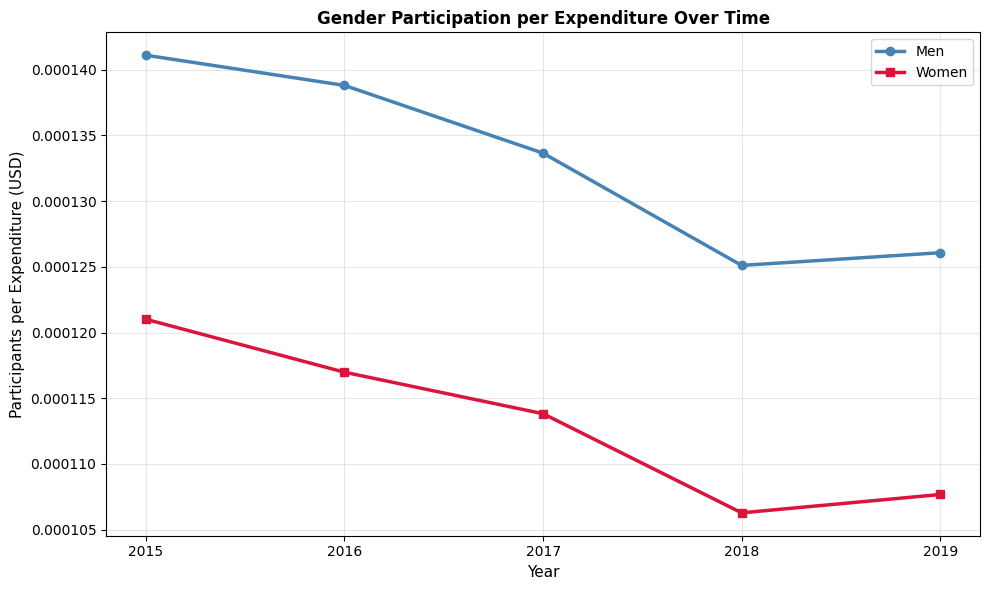

In [ ]:
# PARTICIPATION VS. EXPENDITURE:

sports2 = df.copy()
sports2 = sports2[(sports2['total_exp_menwomen'] > 0) & (sports2['sum_partic_men'] > 0) &
                   (sports2['total_exp_menwomen'] > 0) & (sports2['sum_partic_women'] > 0)]

sports2['men_partic_exp'] = sports2['sum_partic_men'] / sports2['total_exp_menwomen']
sports2['women_partic_exp'] = sports2['sum_partic_women'] / sports2['total_exp_menwomen']

yearly_rev_partic = sports2.groupby('year').agg({
    'men_partic_exp': 'mean',
    'women_partic_exp': 'mean'
}).reset_index()

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['men_partic_exp'],
         marker='o', color='steelblue', linewidth=2.5, markersize=6, label='Men')
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['women_partic_exp'],
         marker='s', color='crimson', linewidth=2.5, markersize=6, label='Women')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Participants per Expenditure (USD)', fontsize=11)
plt.title('Gender Participation per Expenditure Over Time', fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_rev_partic['year'].unique())
plt.tight_layout()
plt.show()
